# MLP from Scratch on MNIST

This notebook implements a Multi-Layer Perceptron (MLP) for MNIST digit classification **without using PyTorch built-in functions or autograd**.

The goal is to understand:

- how the forward pass computes predictions
- how cross-entropy loss is computed from logits
- how gradients are manually derived using the chain rule
- how parameters are updated using gradient descent

This is a playground project for learning the internal mechanics of neural networks.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

## Dataset: MNIST

MNIST is a dataset consisting of grayscale images of handwritten digits (0–9). In this notebook, I use `torchvision.datasets` to load the dataset and `DataLoader` to handle batching and shuffling during training.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Basic Building Blocks

I implement three basic functions manually:

1. `relu`: the hidden-layer activation function  
2. `softmax`: converts logits into class probabilities  
3. `cross_entropy_loss`: measures prediction error for classification (this function is used only for tracking the loss, as the gradients are manually computed during optimization)

The softmax function is written in a numerically stable way by subtracting the maximum logit before applying `exp`.


In [ ]:
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax(logits):
    z = logits - torch.max(logits, dim=1, keepdim=True).values
    exp_z = torch.exp(z)
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

def cross_entropy_loss(logits, labels):
    z = logits - torch.max(logits, dim=1, keepdim=True).values
    log_sum_exp = torch.log(torch.sum(torch.exp(z), dim=1))
    correct_logits = z[torch.arange(z.shape[0]), labels]
    return (-correct_logits + log_sum_exp).mean()

## Model architecture

Below is an implementation of a basic MLP containing $L$ hidden layers, where each layer has $H$ hidden nodes.

In [ ]:
class MLP:
    def __init__(self, input_dim, hidden_dim=64, num_layer=3, num_class=10):

        self.num_layer = num_layer
        self.params = {}
        
        self.params[f"w_1"] = torch.rand(hidden_dim, input_dim) * (2.0 / input_dim) ** 0.5
        self.params[f"b_1"] = torch.zeros(hidden_dim)
        
        for l in range(2, self.num_layer+1):
            self.params[f"w_{l}"] = torch.rand(hidden_dim, hidden_dim) * (2.0 / hidden_dim) ** 0.5
            self.params[f"b_{l}"] = torch.zeros(hidden_dim)
        
        self.params[f"w_out"] = torch.rand(num_class, hidden_dim) * (2.0 / hidden_dim) ** 0.5
        self.params[f"b_out"] = torch.zeros(num_class)

        self.grads = {}

    def forward(self, x):

        self.cache = {}
        self.cache["a_0"] = x

        z = x @ self.params[f"w_1"].T + self.params[f"b_1"]
        a = relu(z)

        self.cache["z_1"] = z
        self.cache["a_1"] = a
        
        for l in range (2, self.num_layer+1):
            z = a @ self.params[f"w_{l}"].T + self.params[f"b_{l}"]
            a = relu(z)

            self.cache[f"z_{l}"] = z
            self.cache[f"a_{l}"] = a
            
        logits = a @ self.params[f"w_out"].T + self.params[f"b_out"]
        self.cache["logits"] = logits
        
        return logits

    def backward(self, labels):
        batch_size = labels.shape[0]
        
        probs = softmax(self.cache["logits"])
        
        y_onehot = torch.eye(probs.shape[1])[labels]

        dlogits = (probs - y_onehot) / batch_size
        
        a_last = self.cache[f"a_{self.num_layer}"]

        self.grads["w_out"] = dlogits.T @ a_last
        self.grads["b_out"] = torch.sum(dlogits, dim=0)
        da = dlogits @ self.params["w_out"]

        for l in range(self.num_layer, 0, -1):
            z = self.cache[f"z_{l}"]
            a_prev = self.cache[f"a_{l-1}"]

            relu_grad = (z > 0).float()
            dz = da * relu_grad

            self.grads[f"w_{l}"] = dz.T @ a_prev
            self.grads[f"b_{l}"] = torch.sum(dz, dim=0)

            da = dz @ self.params[f"w_{l}"]

input_dim = 784
hidden_dim = 64
num_layer = 3
num_classes = 10

net = MLP(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layer=num_layer,
    num_class=num_classes
)
        

## Mathematical description of model implementation
### Forward Pass

Given the implemented code for the forward pass:

> ```python
> 
>     def forward(self, x):
> 
>         self.cache = {}
>         self.cache["a_0"] = x
> 
>         z = x @ self.params[f"w_1"].T + self.params[f"b_1"]
>         a = relu(z)
> 
>         self.cache["z_1"] = z
>         self.cache["a_1"] = a
>         
>         for l in range (2, self.num_layer+1):
>             z = a @ self.params[f"w_{l}"].T + self.params[f"b_{l}"]
>             a = relu(z)
> 
>             self.cache[f"z_{l}"] = z
>             self.cache[f"a_{l}"] = a
>             
>         logits = a @ self.params[f"w_out"].T + self.params[f"b_out"]
>         self.cache["logits"] = logits
>         
>         return logits
> 
> ```


The model is a Multilayer Perceptron (MLP) consisting of $L$ hidden layers. During the forward pass, each layer applies a linear transformation followed by a non-linear activation function.

For the $l$-th hidden layer, the computation is:

$$
\mathbf{z}_{l} = \mathbf{a}_{l-1} \mathbf{W}_{l}^T + \mathbf{b}_{l},
$$

$$
\mathbf{a}_{l} = \text{ReLU}(\mathbf{z}_{l}),
$$

where $\mathbf{a}_{l-1}$ is the activation from the previous layer, and $\mathbf{a}_{l}$ is the output of the current layer.

In code, it is implemented as:

> ```python
>
> for l in range (2, self.num_layer+1):
>     z = a @ self.params[f"w_{l}"].T + self.params[f"b_{l}"]
>     a = relu(z)
>
> ```

After the hidden layers, the output layer produces the logits (unnormalized scores):

$$
\mathbf{Z}_{out} = \mathbf{a}_{L} \mathbf{W}_{out}^T + \mathbf{b}_{out},
$$

It is implemented as:

> ```python
> 
> logits = a @ self.params[f"w_out"].T + self.params[f"b_out"]
> 
> ```

These logits are later converted into probabilities using the softmax function.

### Backward Pass


Given the implemented code for the backward pass:

> ```python
> 
> def backward(self, labels):
>         batch_size = labels.shape[0]
>         
>         probs = softmax(self.cache["logits"]) #Step 1
> 
>         y_onehot = torch.eye(probs.shape[1])[labels]
> 
>         dlogits = (probs - y_onehot) / batch_size #Step 2
>         
>         a_last = self.cache[f"a_{self.num_layer}"]
> 
>         self.grads["w_out"] = dlogits.T @ a_last #Step 3
>         self.grads["b_out"] = torch.sum(dlogits, dim=0) #Step 4
>         da = dlogits @ self.params["w_out"]
> 
>         for l in range(self.num_layer, 0, -1):
>             z = self.cache[f"z_{l}"]
>             a_prev = self.cache[f"a_{l-1}"]
> 
>             relu_grad = (z > 0).float() #Step 5
>             dz = da * relu_grad
> 
>             self.grads[f"w_{l}"] = dz.T @ a_prev # Step 6
>             self.grads[f"b_{l}"] = torch.sum(dz, dim=0)
> 
>             da = dz @ self.params[f"w_{l}"]
> 
> ```

The backward pass process is divided into six steps for easier understanding:

- Step 1: Compute the probabilities using the softmax function
- Step 2: Compute the gradient with respect to the logits
- Step 3: Compute the gradient with respect to the output weights
- Step 4: Compute the gradient with respect to the output bias
- Step 5: Compute the gradient through the last activation
- Step 6: Compute the gradients for the hidden layers

Before diving into the backward pass process, the logits obtained from the forward pass are first converted into probabilities using the softmax function:

$$
p_c = \frac{e^{z_{out}^{c}}}{\sum\limits_{k=1}^{C} e^{z_{out}^{k}}},
$$

where $C$ is the number of classes and $p_c$ is the predicted probability for class $c$.

It is implemented as:
> ```python
> 
> probs = softmax(self.cache["logits"])
> 
> ```


Next, we manually compute gradients.

#### Step 1: Compute cross-entropy loss

Given the ground-truth class $t$, the cross-entropy loss is defined as:

$$
\mathcal{L} = -\log(p_{t}) = -\log \left( \frac{e^{z_{out}^{t}}}{\sum\limits_{k=1}^{C} e^{z_{out}^{k}}} \right).
$$

Using logarithmic properties, this can be rearranged as:

$$
\mathcal{L} = - z_{out}^{t} + \log \sum\limits_{k=1}^{C} e^{z_{out}^{k}}.
$$


#### Step 2: Compute gradient with respect to logits

We compute the gradient of the loss with respect to each logit $z_{out}^{k}$:

$$
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}} = -\frac{\partial z_{out}^{t}}{\partial z_{out}^{k}} + \frac{\partial}{\partial z_{out}^{k}} \left( \log \sum\limits_{j=1}^{C} e^{z_{out}^{j}} \right).
$$

###### First term

The derivative of $z_{out}^{t}$ with respect to $z_{out}^{k}$ is:

$$
\frac{\partial z_{out}^{t}}{\partial z_{out}^{k}} =
\begin{cases}
1 & \text{if } k = t \\
0 & \text{if } k \neq t
\end{cases}
$$

This can be written as a one-hot vector:

$$
\frac{\partial z_{out}^{t}}{\partial z_{out}^{k}} = y_k,
$$

where $\mathbf{y}$ is the one-hot encoded label.

###### Second term

Let:

$$
S = \sum\limits_{j=1}^{C} e^{z_{out}^{j}}.
$$

Then:

$$
\frac{\partial}{\partial z_{out}^{k}} \log S = \frac{1}{S} \frac{\partial S}{\partial z_{out}^{k}}.
$$

Since only the $k$-th term depends on $z_{out}^{k}$:

$$
\frac{\partial S}{\partial z_{out}^{k}} = e^{z_{out}^{k}}.
$$

Therefore:

$$
\frac{\partial}{\partial z_{out}^{k}} \log S = \frac{e^{z_{out}^{k}}}{\sum\limits_{j=1}^{C} e^{z_{out}^{j}}} = p_k.
$$


Combining both terms:

$$
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}} = p_k - y_k.
$$

The gradient of the cross-entropy loss with softmax simplifies to the difference between the predicted probabilities and the one-hot labels.

In code, this appears as:

> ```python
> 
> dlogits = (probs - y_onehot) / batch_size
> 
> ```

It is divide by `batch_size` because the loss is averaged over the batch.



#### Step 3: Compute gradient with respect to the output weights

For the output layer, the logits are computed as:

$$
\mathbf{z}_{out} = \mathbf{a}_{L} \mathbf{W}_{out}^T + \mathbf{b}_{out}.
$$

For a single sample, the $k$-th logit is:

$$
z_{out}^{k}
=
\sum_{h=1}^{H} W_{out}^{(k,h)} a_L^h + b_{out}^{k},
$$

where $H$ is the number of hidden units.

We compute the gradient of the loss with respect to each output weight $W_{out}^{(k,h)}$ using the chain rule:

$$
\frac{\partial \mathcal{L}}{\partial W_{out}^{(k,h)}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}
\frac{\partial z_{out}^{k}}{\partial W_{out}^{(k,h)}}.
$$

From the definition of $z_{out}^{k}$:

$$
z_{out}^{k}
=
\sum_{h=1}^{H} W_{out}^{(k,h)} a_L^h + b_{out}^{k},
$$

only the term $W_{out}^{(k,h)}a_L^h$ depends on $W_{out}^{(k,h)}$. Therefore:

$$
\frac{\partial z_{out}^{k}}{\partial W_{out}^{(k,h)}}
=
a_L^h.
$$

Substituting this back gives:

$$
\frac{\partial \mathcal{L}}{\partial W_{out}^{(k,h)}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}} a_L^h.
$$

In code, this appears as:
> ```python
> 
> self.grads["w_out"] = dlogits.T @ a_last
> 
> ```

So each output weight gradient is the product of the upstream gradient and the corresponding hidden activation.


#### Step 4: Compute gradient with respect to the output bias

Next, we compute the gradient of the loss with respect to each output bias $b_{out}^{k}$:

$$
\frac{\partial \mathcal{L}}{\partial b_{out}^{k}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}
\frac{\partial z_{out}^{k}}{\partial b_{out}^{k}}.
$$

Since:

$$
z_{out}^{k}
=
\sum_{h=1}^{H} W_{out}^{(k,h)} a_L^h + b_{out}^{k},
$$

we have:

$$
\frac{\partial z_{out}^{k}}{\partial b_{out}^{k}}
=
1.
$$

Therefore:

$$
\frac{\partial \mathcal{L}}{\partial b_{out}^{k}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}.
$$

This is implemented as:
> ```python
> 
> self.grads["b_out"] = torch.sum(dlogits, dim=0)
> 
> ```



#### Step 5: Compute gradient with respect to the final hidden layer output

Finally, we compute the gradient of the loss with respect to each output value from the final hidden layer, denoted as $a_L^h$.

Each hidden output $a_L^h$ contributes to all output logits, not just a single logit. Therefore, we need to sum over all output classes:

$$
\frac{\partial \mathcal{L}}{\partial a_L^h}
=
\sum_{k=1}^{C}
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}
\frac{\partial z_{out}^{k}}{\partial a_L^h},
$$

where $C$ is the number of output classes.

From:

$$
z_{out}^{k}
=
\sum_{h=1}^{H} W_{out}^{(k,h)} a_L^h + b_{out}^{k},
$$

only the term $W_{out}^{(k,h)}a_L^h$ depends on $a_L^h$, so:

$$
\frac{\partial z_{out}^{k}}{\partial a_L^h}
=
W_{out}^{(k,h)}.
$$

Therefore:

$$
\frac{\partial \mathcal{L}}{\partial a_L^h}
=
\sum_{k=1}^{C}
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}
W_{out}^{(k,h)}.
$$

This gradient is then passed backward to the previous hidden layer.

In code, this appears as:

> ```python
> 
> da = dlogits @ self.params["w_out"]
> 
> ```



#### Step 6: Compute gradient with respect to hidden layers

For each hidden layer:

$$
\mathbf{z}_{l} = \mathbf{a}_{l-1} \mathbf{W}_{l}^T + \mathbf{b}_{l},
$$

$$
\mathbf{a}_{l} = \text{ReLU}(\mathbf{z}_{l}).
$$

##### Step 6.1: Backpropagation through the activation

To understand the backward pass, we first consider the last hidden layer ($l = L$).

We compute the gradient of the loss with respect to $z_{L}^{h}$ using the chain rule:

$$
\frac{\partial \mathcal{L}}{\partial z_{L}^{h}}
=
\frac{\partial \mathcal{L}}{\partial a_{L}^{h}}
\cdot
\frac{\partial a_{L}^{h}}{\partial z_{L}^{h}}.
$$

The term $\frac{\partial \mathcal{L}}{\partial a_{L}^{h}}$ is obtained from the previous layer (output layer backpropagation).

Since the activation function is ReLU:

$$
a_{L}^{h} = \text{ReLU}(z_{L}^{h}),
$$

its derivative is:

$$
\frac{\partial a_{L}^{h}}{\partial z_{L}^{h}} =
\text{ReLU}'(z_{L}^{h}) =
\begin{cases}
1 & \text{if } z_{L}^{h} > 0 \\
0 & \text{otherwise}
\end{cases}.
$$

Therefore:

$$
\frac{\partial \mathcal{L}}{\partial z_{L}^{h}}
=
\frac{\partial \mathcal{L}}{\partial a_{L}^{h}}
\cdot
\text{ReLU}'(z_{L}^{h}).
$$

In code, this appears as:

> ```python
> 
> for l in range(self.num_layer, 0, -1):
>     ...
> 
>     relu_grad = (z > 0).float()
>     dz = da * relu_grad
> 
>     ...
> 
> ```

##### Step 6.2: Compute gradients for a general layer

From the output layer, we already know:

$$
\frac{\partial \mathcal{L}}{\partial W_{out}^{(k,h)}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}} \, a_L^h,
$$

$$
\frac{\partial \mathcal{L}}{\partial b_{out}^{k}}
=
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}},
$$

$$
\frac{\partial \mathcal{L}}{\partial a_L^h}
=
\sum_{k=1}^{C}
\frac{\partial \mathcal{L}}{\partial z_{out}^{k}}
W_{out}^{(k,h)}.
$$

These results generalize to any layer $l$:

$$
\frac{\partial \mathcal{L}}{\partial W_{l}^{(k,h)}}
=
\frac{\partial \mathcal{L}}{\partial z_{l}^{k}} \, a_{l-1}^{h},
$$

$$
\frac{\partial \mathcal{L}}{\partial b_{l}^{k}}
=
\frac{\partial \mathcal{L}}{\partial z_{l}^{k}},
$$

$$
\frac{\partial \mathcal{L}}{\partial a_{l}^{h}}
=
\sum_{k}
\frac{\partial \mathcal{L}}{\partial z_{l}^{k}}
W_{l}^{(k,h)}.
$$

Incode, this appears as:

> ```python
> for l in range(self.num_layer, 0, -1):
>     ...
>
>     self.grads[f"w_{l}"] = dz.T @ a_prev
>     self.grads[f"b_{l}"] = torch.sum(dz, dim=0)
> 
>     da = dz @ self.params[f"w_{l}"]
> 
> ```

## Training and Evaluation Functions

The model is trained using plain gradient descent without relying on PyTorch autograd. During training, the model learns by repeatedly adjusting its parameters to minimize the classification loss on the MNIST dataset.

Each training iteration consists of four main steps:

1. **Forward pass**  
   The input images are passed through the network to compute the output logits.

2. **Loss computation**  
   The logits are compared with the ground-truth labels using the cross-entropy loss function to measure the prediction error.

3. **Backward pass**  
   Gradients of the loss with respect to all trainable parameters are manually computed using backpropagation and the chain rule.

4. **Parameter update**  
   The model parameters are updated using gradient descent to reduce the loss.

The parameter update rule is:

$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

where:

- $\theta$ represents the model parameters,
- $\eta$ is the learning rate,
- $\nabla_\theta L$ is the gradient of the loss with respect to the parameters.

This process is repeated for many iterations until the model gradually learns to classify handwritten digits correctly.

In [5]:
def train(net, train_loader, lr, epoch, epochs, interval=200):
    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{epochs}")

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for iteration, (images, labels) in enumerate(pbar):

        batch_size, channel, height, width = images.shape
        x = images.view(batch_size, -1)

        logits = net.forward(x)
        loss = cross_entropy_loss(logits, labels)
        net.backward(labels)

        for name in net.params:
            net.params[name] -= lr * net.grads[name]

        preds = torch.argmax(logits, dim=1)
        correct = (preds == labels).sum().item()

        total_loss += loss.item() * batch_size
        total_correct += correct
        total_samples += batch_size

        if iteration % interval == 0:
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{correct / batch_size:.4f}"
            })

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def test(net, test_loader):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in test_loader:

        batch_size, channel, height, width = images.shape
        x = images.view(batch_size, -1)

        logits = net.forward(x)
        loss = cross_entropy_loss(logits, labels)

        preds = torch.argmax(logits, dim=1)
        correct = (preds == labels).sum().item()

        total_loss += loss.item() * batch_size
        total_correct += correct
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc



## Run Training


In [6]:
lr = 0.001
epochs = 20

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(epochs):

    train_loss, train_acc = train(
        net=net,
        train_loader=train_loader,
        lr=lr,
        epoch=epoch,
        epochs=epochs,
    )

    test_loss, test_acc = test(
        net=net,
        test_loader=test_loader
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
        f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}"
    )

Train Epoch 1/20:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1/20 | train loss: 3.6804, train acc: 0.2094 | test loss: 2.1307, test acc: 0.2388


Train Epoch 2/20:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 2/20 | train loss: 2.0768, train acc: 0.3077 | test loss: 1.9974, test acc: 0.3259


Train Epoch 3/20:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Epoch 18/20 | train loss: 0.2910, train acc: 0.9162 | test loss: 0.2818, test acc: 0.9163


Train Epoch 19/20:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 19/20 | train loss: 0.2780, train acc: 0.9195 | test loss: 0.2675, test acc: 0.9202


Train Epoch 20/20:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 20/20 | train loss: 0.2661, train acc: 0.9231 | test loss: 0.2583, test acc: 0.9251


## Training Curves


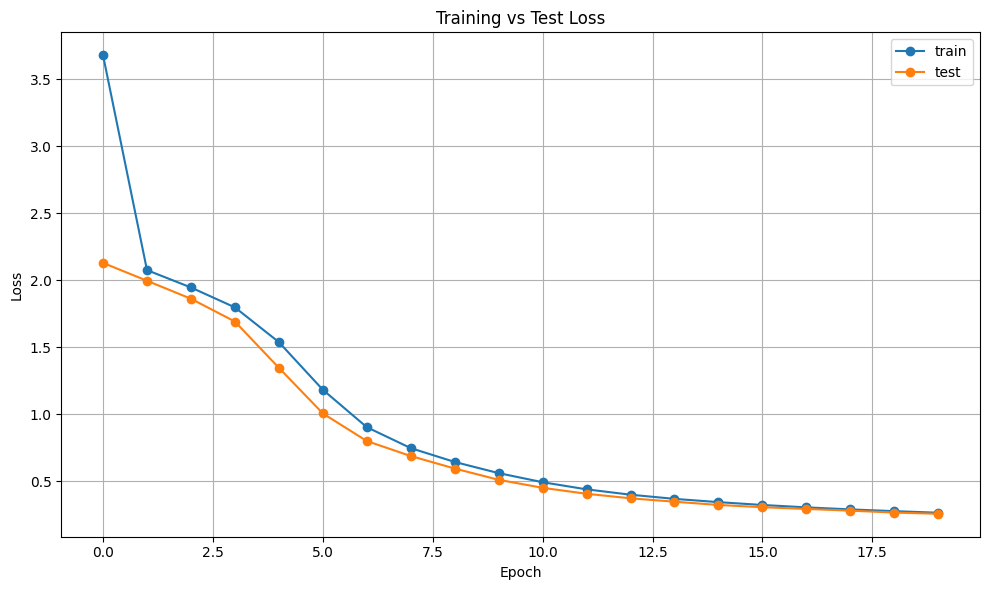

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, marker='o', label="train")
plt.plot(test_losses, marker='o', label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

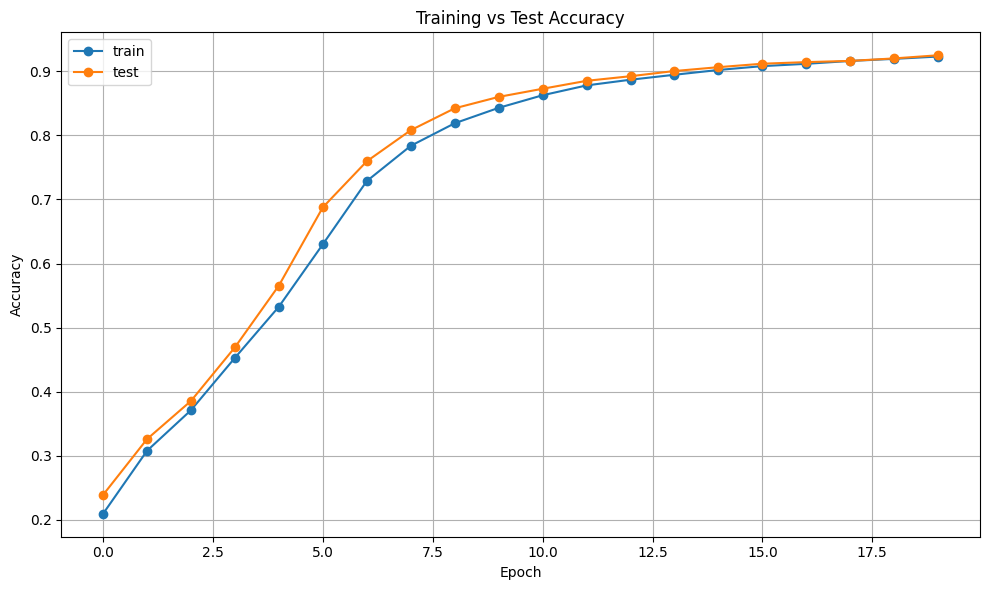

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(train_accs, marker='o', label="train")
plt.plot(test_accs, marker='o', label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


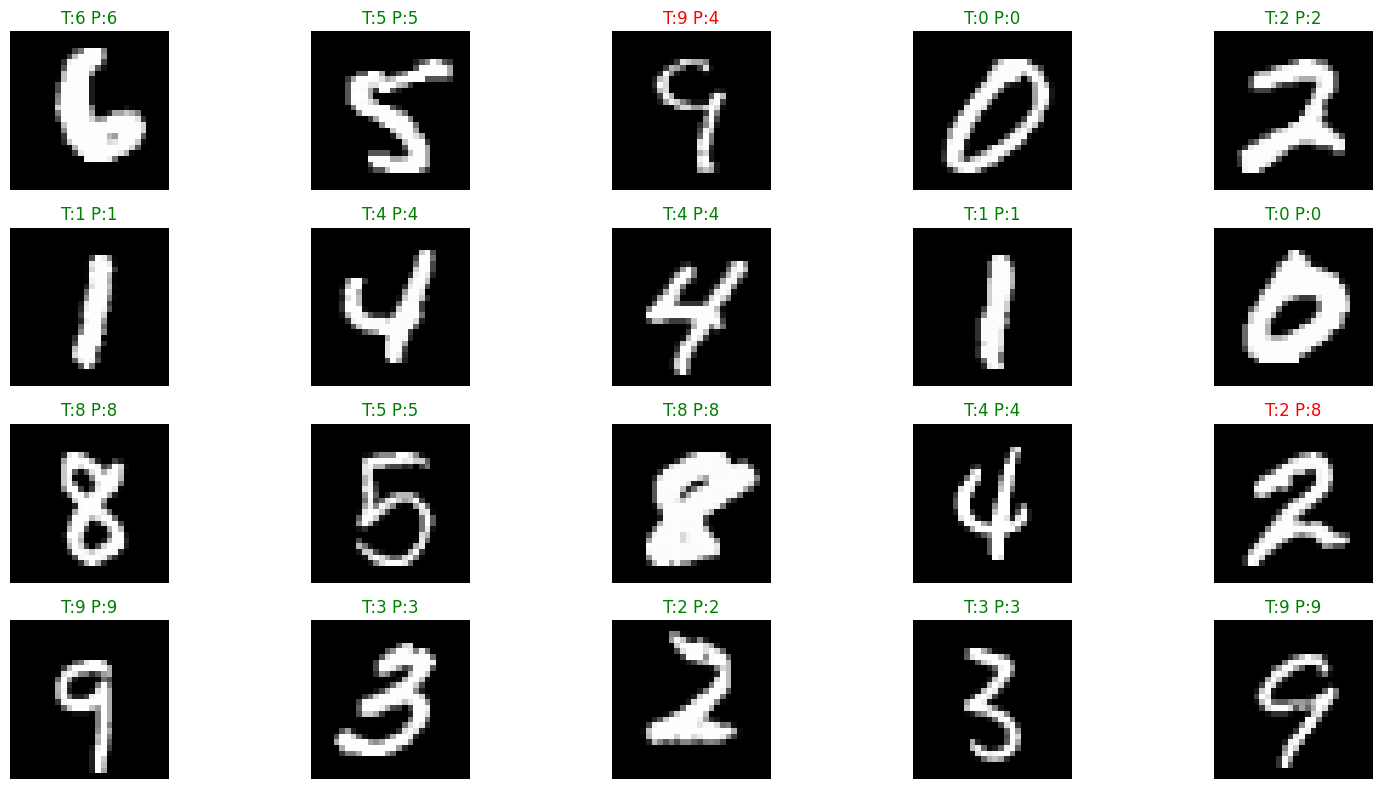

In [9]:
num_samples=20

indices = torch.randperm(len(test_dataset))[:num_samples]
samples = [test_dataset[i] for i in indices]

images = torch.stack([s[0] for s in samples])
labels = torch.tensor([s[1] for s in samples])

x = images.view(num_samples, -1)
logits = net.forward(x)
preds = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(4, 5, figsize=(16, 8))
axes = axes.flatten()

for i in range(num_samples):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"T:{labels[i].item()} P:{preds[i].item()}",
                      color=("green" if preds[i] == labels[i] else "red"))
    axes[i].axis('off')

plt.tight_layout()
plt.show()